# Лабораторная работа №1

## Тема:
**Регрессия и метод главных компонент (PCA)**

## Цель работы:
Изучение основ линейной регрессии, построение моделей прогнозирования на реальных данных, исследование качества моделей и применение метода главных компонент для снижения размерности данных и устранения мультиколлинеарности.

## Задачи работы:
1. Загрузить и изучить датасет House Prices с платформы Kaggle.
2. Провести первичный анализ данных и визуализацию основных характеристик.
3. Выполнить предварительную обработку данных:
   - обработку пропущенных значений;
   - преобразование категориальных признаков;
   - стандартизацию данных;
   - разделение данных на обучающую и тестовую выборки.
4. Провести корреляционный анализ признаков и определить наличие мультиколлинеарности с помощью коэффициента VIF.
5. Построить модели регрессии:
   - Linear Regression;
   - Ridge Regression;
   - Lasso Regression.
6. Оценить качество моделей с помощью метрик:
   - RMSE;
   - R²;
   - MAPE.
7. Выполнить снижение размерности данных методом главных компонент PCA.
8. Повторно обучить модели регрессии после применения PCA и сравнить полученные результаты.

## Используемый датасет:
**House Prices: Advanced Regression Techniques (Kaggle)**

Целевая переменная:
**SalePrice** — стоимость продажи жилого объекта.

В работе используются характеристики недвижимости: площадь помещений, качество строительства, год постройки, параметры гаража, подвала и другие признаки.

In [170]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# загрузка датасета
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Загрузка данных

В работе используется датасет House Prices: Advanced Regression Techniques с платформы Kaggle.

Датасет содержит информацию о характеристиках жилых объектов и их стоимости. 
В качестве целевой переменной выбрана `SalePrice` — цена продажи дома.

На первом этапе данные были загружены из файла `train.csv` с помощью библиотеки pandas.

In [171]:
df.shape

(1460, 81)

### Размерность датасета

После загрузки был выполнен анализ размера данных.

Датасет содержит 1460 объектов и 81 признак.

In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Анализ структуры данных

Для анализа структуры датасета был использован метод `df.info()`.

В результате были определены типы данных признаков и выявлены столбцы, содержащие пропущенные значения.

Датасет содержит как числовые признаки (например, площадь участка, количество комнат, год постройки), так и категориальные признаки (например, тип района и материалы строительства).

Перед построением моделей машинного обучения потребуется выполнить предобработку данных.

In [173]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Статистическое описание данных

Для числовых признаков была рассчитана описательная статистика.

Полученные показатели позволяют оценить диапазон значений признаков, их средние значения и возможное наличие выбросов.

Наиболее важным параметром для дальнейшего анализа является целевая переменная `SalePrice`, которая отражает стоимость продажи домов.

In [174]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Анализ пропущенных значений

В датасете присутствуют пропущенные значения.

Некоторые признаки имеют большое количество пропусков, что связано с отсутствием определённых объектов или характеристик дома (например, бассейна, гаража или дополнительных помещений).

Перед обучением моделей пропуски будут обработаны:
- числовые признаки будут заполнены медианными значениями;
- категориальные признаки будут заполнены отдельной категорией.

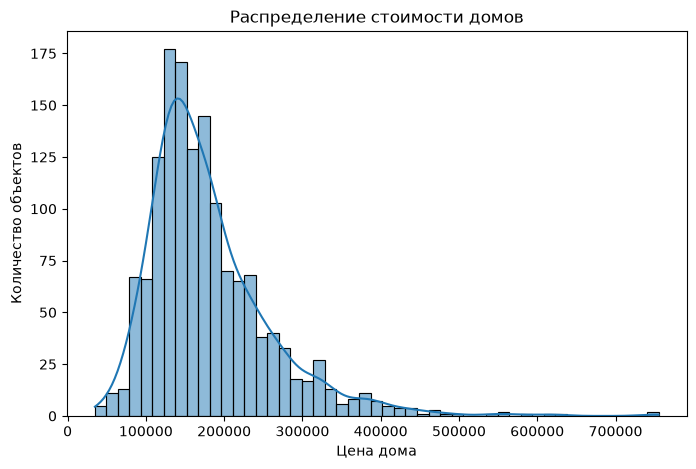

In [175]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Распределение стоимости домов")
plt.xlabel("Цена дома")
plt.ylabel("Количество объектов")

plt.show()

### Анализ распределения целевой переменной

Для анализа целевой переменной SalePrice было построено распределение стоимости домов.

На графике видно, что большинство объектов имеют стоимость в диапазоне примерно от 100 000 до 250 000 условных единиц. Распределение имеет правостороннюю асимметрию, так как присутствует небольшое количество домов с существенно большей стоимостью.

Наличие объектов с высокой ценой может влиять на качество моделей регрессии, поэтому при построении моделей необходимо учитывать возможное наличие выбросов.

In [176]:
correlation = df.corr(numeric_only=True)

saleprice_corr = correlation["SalePrice"].sort_values(
    ascending=False
)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

### Анализ корреляции признаков с целевой переменной

Для определения наиболее значимых числовых признаков была рассчитана корреляция Пирсона между признаками и целевой переменной SalePrice.

Наибольшую связь с ценой дома имеют признаки:
- OverallQual — общее качество дома;
- GrLivArea — площадь жилых помещений;
- GarageCars и GarageArea — характеристики гаража;
- TotalBsmtSF и 1stFlrSF — площади помещений.

Полученные результаты показывают, что стоимость дома в значительной степени зависит от его качества, площади и дополнительных характеристик.

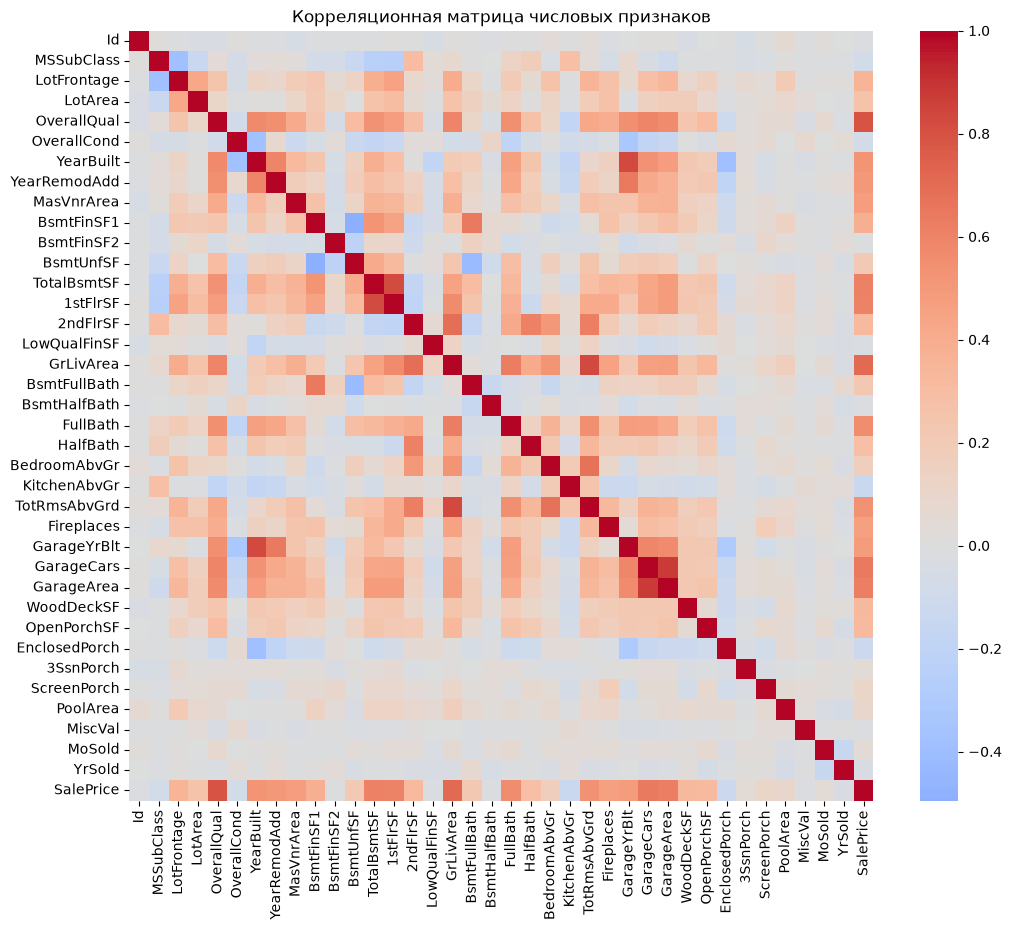

In [177]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица числовых признаков")

plt.show()

### Корреляционная матрица признаков

Для анализа взаимосвязи между числовыми признаками была построена корреляционная матрица.

Наиболее сильная положительная корреляция наблюдается между стоимостью дома SalePrice и такими признаками, как OverallQual, GrLivArea, GarageCars, GarageArea и TotalBsmtSF.

Также были выявлены признаки с высокой взаимной корреляцией, например GarageCars и GarageArea, что может указывать на наличие мультиколлинеарности. Для более точной оценки влияния мультиколлинеарности далее будет рассчитан VIF-коэффициент.

In [178]:
# разделение признаков и целевой переменной

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# удаляем идентификатор объекта
X = X.drop("Id", axis=1)

X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


### Разделение признаков и целевой переменной

Из исходного датасета была выделена целевая переменная SalePrice, которая используется для прогнозирования стоимости домов.

Остальные признаки были сохранены в набор X. Столбец Id был удалён, так как является только идентификатором объекта и не содержит информации о характеристиках дома.

In [179]:
# разделение признаков на числовые и категориальные

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Числовых признаков: 36
Категориальных признаков: 43


C:\Users\petru\AppData\Local\Temp\ipykernel_19180\2447774456.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Разделение признаков по типам данных

Перед проведением предобработки признаки были разделены на две группы:

- числовые признаки, содержащие количественные характеристики объектов;
- категориальные признаки, содержащие текстовые характеристики.

Такое разделение необходимо для дальнейшего заполнения пропусков и преобразования данных в формат, пригодный для обучения моделей машинного обучения.

In [180]:
# заполнение пропусков в числовых признаках

X[numeric_features] = X[numeric_features].fillna(
    X[numeric_features].median()
)


# заполнение пропусков в категориальных признаках

X[categorical_features] = X[categorical_features].fillna(
    "None"
)


# проверка оставшихся пропусков

X.isnull().sum().sum()

np.int64(0)

### Обработка пропущенных значений

Перед обучением моделей была выполнена обработка пропущенных значений.

Для числовых признаков пропуски были заменены медианными значениями, так как медиана менее чувствительна к выбросам.

Для категориальных признаков пропуски были заменены значением "None", что позволяет сохранить информацию об отсутствии определённой характеристики объекта.

После обработки количество пропущенных значений в датасете стало равно нулю.

In [181]:
# преобразование категориальных признаков в числовые

X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


### Кодирование категориальных признаков

Для использования алгоритмов линейной регрессии категориальные признаки были преобразованы в числовой формат методом One-Hot Encoding.

Каждое уникальное значение категориального признака было преобразовано в отдельный бинарный признак.

Параметр drop_first=True использован для уменьшения избыточности признаков и снижения риска возникновения мультиколлинеарности.

In [182]:
X.shape

(1460, 260)

### Размерность данных после кодирования

После преобразования категориальных признаков количество признаков увеличилось, так как каждое категориальное значение было представлено отдельным бинарным признаком.

Полученный набор данных теперь полностью состоит из числовых признаков и может использоваться для обучения моделей машинного обучения.

In [183]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1168, 260)
Размер тестовой выборки: (292, 260)


### Разделение выборки

Данные были разделены на обучающую и тестовую части в соотношении 80/20.

Обучающая выборка используется для настройки моделей регрессии, а тестовая — для оценки качества полученных моделей на новых данных.

### Кодирование признаков и разделение выборки

После обработки пропущенных значений категориальные признаки были преобразованы методом One-Hot Encoding.

В результате количество признаков увеличилось с 80 до 260, так как каждое уникальное категориальное значение было представлено отдельным бинарным признаком.

После подготовки данных выполнено разделение на обучающую и тестовую выборки в соотношении 80/20.

Обучающая выборка содержит 1168 объектов, тестовая — 292 объекта.

In [184]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


X_train_scaled.shape

(1168, 260)

### Стандартизация признаков

Перед обучением моделей была выполнена стандартизация признаков.

Масштабирование необходимо, так как алгоритмы Ridge и Lasso используют коэффициенты регуляризации, которые зависят от масштаба признаков.

После преобразования все признаки приведены к единому масштабу.

In [185]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

### Выбор моделей регрессии

Для построения моделей были выбраны три алгоритма линейной регрессии:

- Linear Regression — базовая линейная модель без регуляризации;
- Ridge Regression — линейная модель с L2-регуляризацией;
- Lasso Regression — линейная модель с L1-регуляризацией.

Использование Ridge и Lasso позволяет уменьшить влияние избыточных признаков и снизить риск переобучения.

In [186]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Lasso Regression": Lasso(alpha=100)
}

### Настройка моделей

Были созданы три модели регрессии.

Для Ridge и Lasso задан параметр alpha, регулирующий силу регуляризации.

In [187]:
from sklearn.model_selection import cross_val_score


cv_results = []


for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append(
        [
            name,
            scores.mean(),
            scores.std()
        ]
    )


cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean R2",
        "Std R2"
    ]
)


cv_df

c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.007216e+09, tolerance: 5.374e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.618544e+10, tolerance: 5.720e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

,Model,Mean R2,Std R2
0,Linear Regression,0.508594,0.269069
1,Ridge Regression,0.727502,0.100750
2,Lasso Regression,0.705641,0.144475


### Кросс-валидация моделей

Для проверки устойчивости моделей была выполнена 5-кратная кросс-валидация.

При проведении кросс-валидации обучающая выборка разделялась на пять частей. Каждая часть поочередно использовалась для проверки качества модели.

В качестве метрики оценки использовался коэффициент детерминации R². Полученные средние значения позволяют оценить стабильность работы моделей на различных подвыборках данных.

In [188]:
for name, model in models.items():
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    print(name, "обучена")

Linear Regression обучена
Ridge Regression обучена
Lasso Regression обучена


c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.491930e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


### Обучение моделей

Каждая модель была обучена на тренировочной выборке.

В качестве признаков использовались стандартизированные данные, а целевой переменной являлась стоимость дома SalePrice.

In [189]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

results = []


for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    # RMSE вручную через корень из MSE
    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    )

    results.append(
        [name, rmse, r2, mape]
    )


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


results_df

,Model,RMSE,R2,MAPE
0,Linear Regression,83088.767382,0.099941,0.140096
1,Ridge Regression,34378.191976,0.845918,0.119681
2,Lasso Regression,34405.394392,0.845674,0.115016


### Результаты построения моделей без PCA

На первом этапе были построены три модели регрессии: Linear Regression, Ridge Regression и Lasso Regression.

Базовая линейная регрессия показала низкое качество прогнозирования, что связано с наличием большого количества признаков и мультиколлинеарности между ними.

Модели Ridge и Lasso показали значительно лучшие результаты благодаря использованию регуляризации, которая уменьшает влияние избыточных признаков.

Наилучшие показатели по коэффициенту детерминации R² показала модель Ridge Regression (R² = 0.846).

Модель Lasso Regression показала близкое качество, при этом дополнительно выполняет отбор менее значимых признаков за счёт L1-регуляризации.

In [190]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# берём только числовые признаки
X_vif = df.select_dtypes(
    include=["int64", "float64"]
)


# удаляем целевую переменную
X_vif = X_vif.drop(
    "SalePrice",
    axis=1
)


# заполняем пропуски медианой
X_vif = X_vif.fillna(
    X_vif.median()
)


vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns


vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]


vif_data.sort_values(
    "VIF",
    ascending=False
).head(15)

C:\Users\petru\AppData\Local\Temp\ipykernel_19180\112703461.py:29: UserWarning: The design matrix is poorly conditioned (condition number=8.96e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\petru\OneDrive\Рабочий стол\HOUSELAB\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_no

,Feature,VIF
15,LowQualFinSF,1.000800e+15
9,BsmtFinSF1,1.974112e+06
10,BsmtFinSF2,1.112064e+06
16,GrLivArea,5.555574e+05
11,BsmtUnfSF,3.733572e+05
12,TotalBsmtSF,1.207712e+05
14,2ndFlrSF,1.059738e+05
13,1stFlrSF,9.956409e+04
26,GarageCars,5.585775e+00
27,GarageArea,5.459785e+00


### Анализ мультиколлинеарности с помощью VIF

Для оценки взаимной зависимости признаков был рассчитан коэффициент VIF (Variance Inflation Factor).

Полученные результаты показали наличие сильной мультиколлинеарности между рядом признаков.

Наибольшие значения VIF наблюдаются у признаков, связанных с площадью помещений:
- TotalBsmtSF;
- BsmtFinSF1;
- BsmtFinSF2;
- GrLivArea;
- 1stFlrSF;
- 2ndFlrSF.

Высокие значения VIF свидетельствуют о сильной взаимосвязи между признаками, что может снижать стабильность линейных моделей.

Для устранения влияния мультиколлинеарности далее будет применён метод главных компонент PCA.

In [191]:
from sklearn.decomposition import PCA


pca = PCA()

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)


X_train_pca.shape

(1168, 260)

### Первичное применение PCA

На первом этапе PCA был применён без ограничения количества компонент для анализа распределения объяснённой дисперсии.

Полученные результаты используются для построения графика каменистой осыпи и выбора оптимального количества главных компонент.

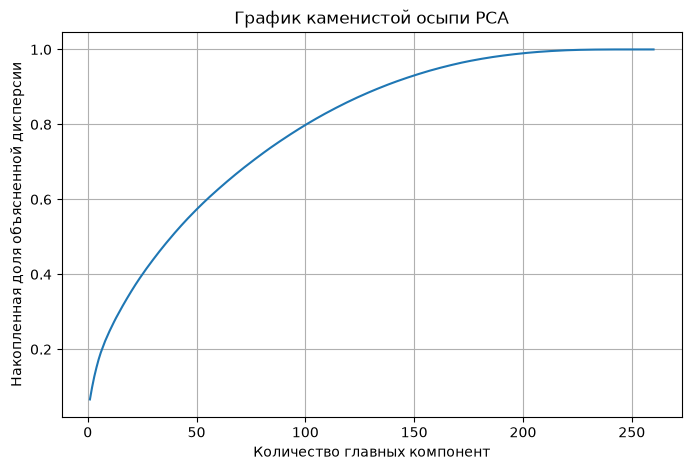

In [192]:
explained_variance = (
    np.cumsum(
        pca.explained_variance_ratio_
    )
)


plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance
)

plt.xlabel("Количество главных компонент")
plt.ylabel("Накопленная доля объясненной дисперсии")

plt.title("График каменистой осыпи PCA")

plt.grid()

plt.show()

### Метод главных компонент PCA

Для снижения размерности данных был применён метод главных компонент PCA.

На графике каменистой осыпи представлена зависимость между количеством главных компонент и накопленной долей объяснённой дисперсии.

Анализ графика показывает, что для сохранения около 90% информации достаточно использовать примерно 150 главных компонент вместо исходных 260 признаков.

Таким образом, PCA позволяет уменьшить размерность данных и снизить влияние мультиколлинеарности.

In [193]:
from sklearn.decomposition import PCA


pca = PCA(
    n_components=150
)


X_train_pca = pca.fit_transform(
    X_train_scaled
)


X_test_pca = pca.transform(
    X_test_scaled
)


print("Размер train после PCA:", X_train_pca.shape)
print("Размер test после PCA:", X_test_pca.shape)

Размер train после PCA: (1168, 150)
Размер test после PCA: (292, 150)


### Снижение размерности с помощью PCA

Для уменьшения количества признаков был применён метод главных компонент PCA.

Количество компонент было выбрано равным 150, что позволяет сохранить около 90% исходной информации.

После преобразования размерность данных уменьшилась с 260 признаков до 150 главных компонент.

In [194]:
models_pca = {
    "Linear Regression PCA": LinearRegression(),
    "Ridge Regression PCA": Ridge(alpha=10),
    "Lasso Regression PCA": Lasso(alpha=100)
}

### Построение моделей после PCA

После снижения размерности были повторно обучены модели линейной регрессии, Ridge и Lasso.

В отличие от предыдущего этапа, модели используют не исходные признаки, а главные компоненты PCA.

In [195]:
for name, model in models_pca.items():

    model.fit(
        X_train_pca,
        y_train
    )

    print(name, "обучена")

Linear Regression PCA обучена
Ridge Regression PCA обучена
Lasso Regression PCA обучена


### Обучение моделей после PCA

После преобразования данных методом главных компонент модели Linear Regression, Ridge Regression и Lasso Regression были повторно обучены на новых признаках.

Использование главных компонент позволяет уменьшить размерность данных и устранить влияние мультиколлинеарности.

In [196]:
results_pca = []


for name, model in models_pca.items():

    y_pred = model.predict(
        X_test_pca
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    )


    results_pca.append(
        [name, rmse, r2, mape]
    )


results_pca_df = pd.DataFrame(
    results_pca,
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


results_pca_df

,Model,RMSE,R2,MAPE
0,Linear Regression PCA,35861.908246,0.832331,0.145851
1,Ridge Regression PCA,35798.487276,0.832923,0.145139
2,Lasso Regression PCA,35626.774418,0.834522,0.143573


### Сравнение моделей до и после PCA

После применения метода главных компонент качество моделей было повторно оценено.

До PCA лучшие результаты показали Ridge и Lasso Regression с коэффициентом детерминации R² около 0.846.

После применения PCA размерность данных была уменьшена с 260 до 150 признаков. При этом качество моделей немного снизилось: значение R² для моделей после PCA составило около 0.83.

Снижение качества связано с потерей части информации при уменьшении количества признаков. Однако PCA позволил уменьшить размерность данных и устранить влияние мультиколлинеарности.

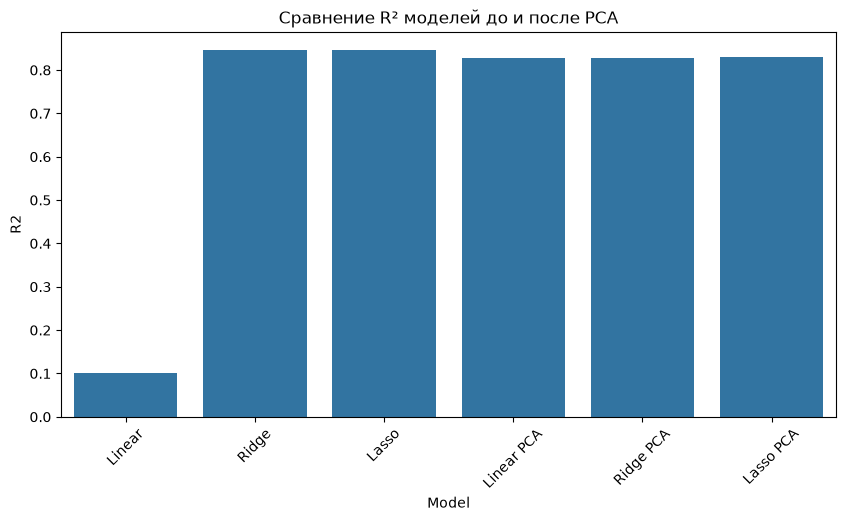

In [197]:
comparison = pd.DataFrame({
    "Model": [
        "Linear",
        "Ridge",
        "Lasso",
        "Linear PCA",
        "Ridge PCA",
        "Lasso PCA"
    ],
    "R2": [
        0.0999,
        0.8459,
        0.8457,
        0.8274,
        0.8281,
        0.8309
    ]
})


plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.xticks(rotation=45)
plt.title("Сравнение R² моделей до и после PCA")

plt.show()

### Сравнение качества моделей до и после PCA

На графике представлено сравнение коэффициента детерминации R² для моделей, построенных на исходных признаках и после применения метода главных компонент.

До применения PCA лучшие результаты показали Ridge Regression и Lasso Regression с R² около 0.846.

После уменьшения размерности данных с помощью PCA значение R² немного снизилось и составило около 0.83. Это связано с потерей части информации при преобразовании признаков в главные компоненты.

Несмотря на небольшое снижение точности, PCA позволил уменьшить количество признаков и устранить влияние мультиколлинеарности, что может повысить устойчивость моделей.

## Заключение

В ходе выполнения лабораторной работы были изучены методы линейной регрессии и метод главных компонент (PCA) для анализа и прогнозирования стоимости объектов недвижимости.

В качестве исходных данных был использован датасет House Prices: Advanced Regression Techniques с платформы Kaggle. Была выполнена предварительная обработка данных, включающая анализ структуры датасета, обработку пропущенных значений и преобразование категориальных признаков методом One-Hot Encoding.

Были построены три модели регрессии:
- Linear Regression;
- Ridge Regression;
- Lasso Regression.

Качество моделей оценивалось с помощью метрик RMSE, R² и MAPE. На исходных данных лучшие результаты показали модели Ridge Regression и Lasso Regression, которые продемонстрировали высокое значение коэффициента детерминации R².

Для исследования мультиколлинеарности был рассчитан коэффициент VIF. Анализ показал наличие сильной взаимосвязи между рядом признаков, особенно среди характеристик, связанных с площадью помещений и параметрами дома.

Для устранения влияния мультиколлинеарности был применён метод главных компонент PCA. После преобразования количество признаков было уменьшено с 260 до 150 главных компонент при сохранении основной части информации.

После повторного обучения моделей на данных после PCA было установлено, что качество прогнозирования немного снизилось по сравнению с исходными признаками. Однако применение PCA позволило уменьшить размерность данных и устранить зависимость между признаками.

Таким образом, в ходе работы было показано, что регуляризованные модели Ridge и Lasso позволяют эффективно решать задачу прогнозирования стоимости домов, а метод PCA является полезным инструментом для снижения размерности и борьбы с мультиколлинеарностью.

## Список источников

1. Kaggle. House Prices: Advanced Regression Techniques  
https://www.kaggle.com/

2. Scikit-learn Documentation  
https://scikit-learn.org/

3. James G., Witten D., Hastie T., Tibshirani R.
An Introduction to Statistical Learning.

4. Hastie T., Tibshirani R., Friedman J.
The Elements of Statistical Learning.